# Cast Vote Records: Twin-Path UMAP and HDBSCAN, 2019-2025
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)
May 2026

Released under a [MIT License](https://opensource.org/licenses/MIT).


This notebook visualizes latent structure in **City of Boulder** ballots from every Boulder County Cast Vote Record currently in `data/processed/` — the public 2023/2024/2025 CVRs plus the 2019/2020/2021/2022 files released through Colorado Open Records Act (CORA) disclosure. The cleaned wide CSVs come from the [`scripts`](scripts) package; rebuild them with `python -m scripts.pipeline`.

Each row of a cleaned CSV is one ballot sheet ([NIST SP 1500-103 §3.5.2](https://doi.org/10.6028/NIST.SP.1500-103)); each ballot-choice column holds the NIST `SelectionPosition::HasIndication` flag — `1` for "the scanner detected a mark," `0` for "the bubble was on the ballot for this style and was not marked," and `NaN` for "the contest was not on the voter's ballot style." Ranked-choice contests have one column per candidate-rank combination (e.g. `Aaron Brockett(1)` for rank 1). See [`AGENTS.md`](AGENTS.md) for the full mapping from Dominion's columns to NIST CDF terminology.

For each election, every City of Boulder ballot is a point in a vote space whose dimensionality ranges from roughly 10 (early coordinated elections) to roughly 200 (presidential generals with judicial retentions and amendments). To find clusters of voters who voted similarly, this notebook applies the **two-pass [McInnes pipeline](https://umap-learn.readthedocs.io/en/latest/clustering.html)** recommended by the UMAP author:

1. **For clustering** — reduce the vote matrix to **10 dimensions** with UMAP (tight neighborhoods, `min_dist=0.0`), then run **HDBSCAN** on the 10-D points.
2. **For visualization** — reduce the same vote matrix *separately* to **2 dimensions** with UMAP (`min_dist=0.1` for visual spread), then color the points by the cluster labels from the higher-dimensional run.

Clustering directly on the 2-D projection is a known antipattern: the 2-D layout discards too much structure and is brittle to the random seed.

**Uncommon libraries:** `umap-learn`, `hdbscan`, `scikit-learn`. Install via `pip install -e ".[analysis]"` or `pip install -r requirements.txt`.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick

import umap
import hdbscan
from sklearn.metrics import adjusted_rand_score

SEED = 42
np.random.seed(SEED)


## Discover available cleaned elections

The notebook reads each ``data/processed/<election_key>-county-wide-by-voter.csv`` (one row per voter, all ballots in the county) and filters in-notebook to voters whose ballot style contains at least one "City of Boulder" contest. Per-voter counts are 1/2 of the per-sheet sheet counts seen in earlier versions, because Dominion CVRs are exported one row per ballot **sheet** and Boulder ballots are often two-sheet — see [AGENTS.md](AGENTS.md) for the merging rationale. An election with zero City of Boulder voters (the 2024 Primary, for example) is silently skipped.


In [2]:
CLEAN_DIR = Path('data/processed')
clean_files = sorted(CLEAN_DIR.glob('*-county-wide-by-voter.csv'))
elections = [p.name.removesuffix('-county-wide-by-voter.csv') for p in clean_files]
print('elections in data/processed/:')
for k in elections:
    print(f'  {k}')


elections in data/processed/:
  2019-Coordinated
  2020-General
  2021-Coordinated
  2022-General
  2023-Coordinated
  2024-General
  2024-Primary
  2025-Coordinated


## Load and build the vote matrix per election

For each election, drop the ID columns and coerce every contest-choice column to numeric. The wide CSV's three-value cell encoding (`1`, `0`, `NaN`) collapses to two values for the embedding: `NaN` ("this contest was not on the voter's ballot style") is filled with `0`. This is appropriate for *clustering* — a voter who could not vote on a contest and a voter who voted "no" on the same contest will not be split by that contest — but for analyses that need to separate **undervote** (eligible, left blank) from **not eligible**, preserve the `NaN`/`0` distinction directly from the wide CSV.


In [3]:
def load_clean(election_key, city_marker='City of Boulder'):
    """Load the countywide per-voter CSV and filter to City of Boulder voters.

    A voter is City of Boulder iff at least one of their contest columns whose
    name contains ``city_marker`` is non-null (i.e. the contest was on their
    ballot style). Drops contest columns that are entirely NaN for the filtered
    subset.
    """
    df = pd.read_csv(CLEAN_DIR / f'{election_key}-county-wide-by-voter.csv', low_memory=False)
    marker_cols = [c for c in df.columns if city_marker in c]
    if not marker_cols:
        return df.iloc[0:0]   # election has no City of Boulder contests
    is_city = df[marker_cols].notna().any(axis=1)
    city = df[is_city].copy()
    keep = [c for c in city.columns if c.startswith('_ID/') or city[c].notna().any()]
    return city.loc[:, keep]

def vote_matrix(df):
    choice_cols = [c for c in df.columns if not c.startswith('_ID/')]
    X = df[choice_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(dtype=np.float32)
    return X, choice_cols

cob = {}
X_by_election = {}
choice_cols_by_election = {}
for k in elections:
    df = load_clean(k)
    X, cols = vote_matrix(df)
    cob[k] = df
    X_by_election[k] = X
    choice_cols_by_election[k] = cols
    print(f'  {k}: {X.shape[0]:>7,} ballots × {X.shape[1]:>3} contest cols')


  2019-Coordinated:  34,955 ballots ×  33 contest cols
  2020-General:  62,781 ballots × 105 contest cols
  2021-Coordinated:  33,636 ballots ×  46 contest cols
  2022-General:  47,773 ballots × 128 contest cols
  2023-Coordinated:  34,149 ballots ×  50 contest cols
  2024-General:  56,670 ballots × 106 contest cols
  2024-Primary:       0 ballots ×  30 contest cols
  2025-Coordinated:  34,028 ballots ×  33 contest cols


## Twin-path UMAP + HDBSCAN

The helper runs the McInnes two-pass pipeline on one vote matrix:

* a **10-D** UMAP with `min_dist=0.0` for clustering input
* a **separate 2-D** UMAP with `min_dist=0.1` for plotting

HDBSCAN's ``min_cluster_size`` scales with ballot count (≈ 2% of ballots) so the cluster count stays in a readable range across elections.


In [6]:
def twin_path_cluster(X, min_cluster_size, min_samples=25):
    """Run McInnes' two-pass UMAP + HDBSCAN."""
    reducer_10d = umap.UMAP(
        n_components=10, n_neighbors=30, min_dist=0.0,
    )
    embedding_10d = reducer_10d.fit_transform(X)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        core_dist_n_jobs=-1,
    )
    labels = clusterer.fit_predict(embedding_10d)

    reducer_2d = umap.UMAP(
        n_components=2, n_neighbors=30, min_dist=0.1,
    )
    embedding_2d = reducer_2d.fit_transform(X)
    return embedding_10d, embedding_2d, labels


def min_cluster_size_for(n_ballots, floor=300):
    return max(floor, n_ballots // 50)


## Run the pipeline per election

Each election takes roughly 30–180 seconds depending on ballot count and contest count. Output is cached in ``results`` and persisted to ``data/processed/`` afterward, so a critic can re-render the visualization without re-embedding.


In [10]:
results = {}
for k in elections:
    if k not in results:
        n = X_by_election[k].shape[0]
        mcs = min_cluster_size_for(n)
        print(f'  {k}  (min_cluster_size={mcs})', flush=True)
        if n > 0:
            e10, e2, labels = twin_path_cluster(X_by_election[k], min_cluster_size=mcs)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = int((labels == -1).sum())
            print(f'    {n_clusters} clusters; {n_noise:,} noise ({n_noise/n:.1%})', flush=True)
            results[k] = {
                'embedding_10d': e10,
                'embedding_2d':  e2,
                'labels':        labels,
                'min_cluster_size': mcs,
                'n_clusters':    n_clusters,
                'n_noise':       n_noise,
            }


  2024-Primary  (min_cluster_size=300)
  2025-Coordinated  (min_cluster_size=680)
    17 clusters; 4,463 noise (13.1%)


## Small-multiples visualization

One panel per election. Each panel uses the *visualization* UMAP coordinates (2-D, with spread) and colors points by the cluster label from the *clustering* UMAP (10-D). Noise points (`-1`) are drawn in light grey under the colored clusters.


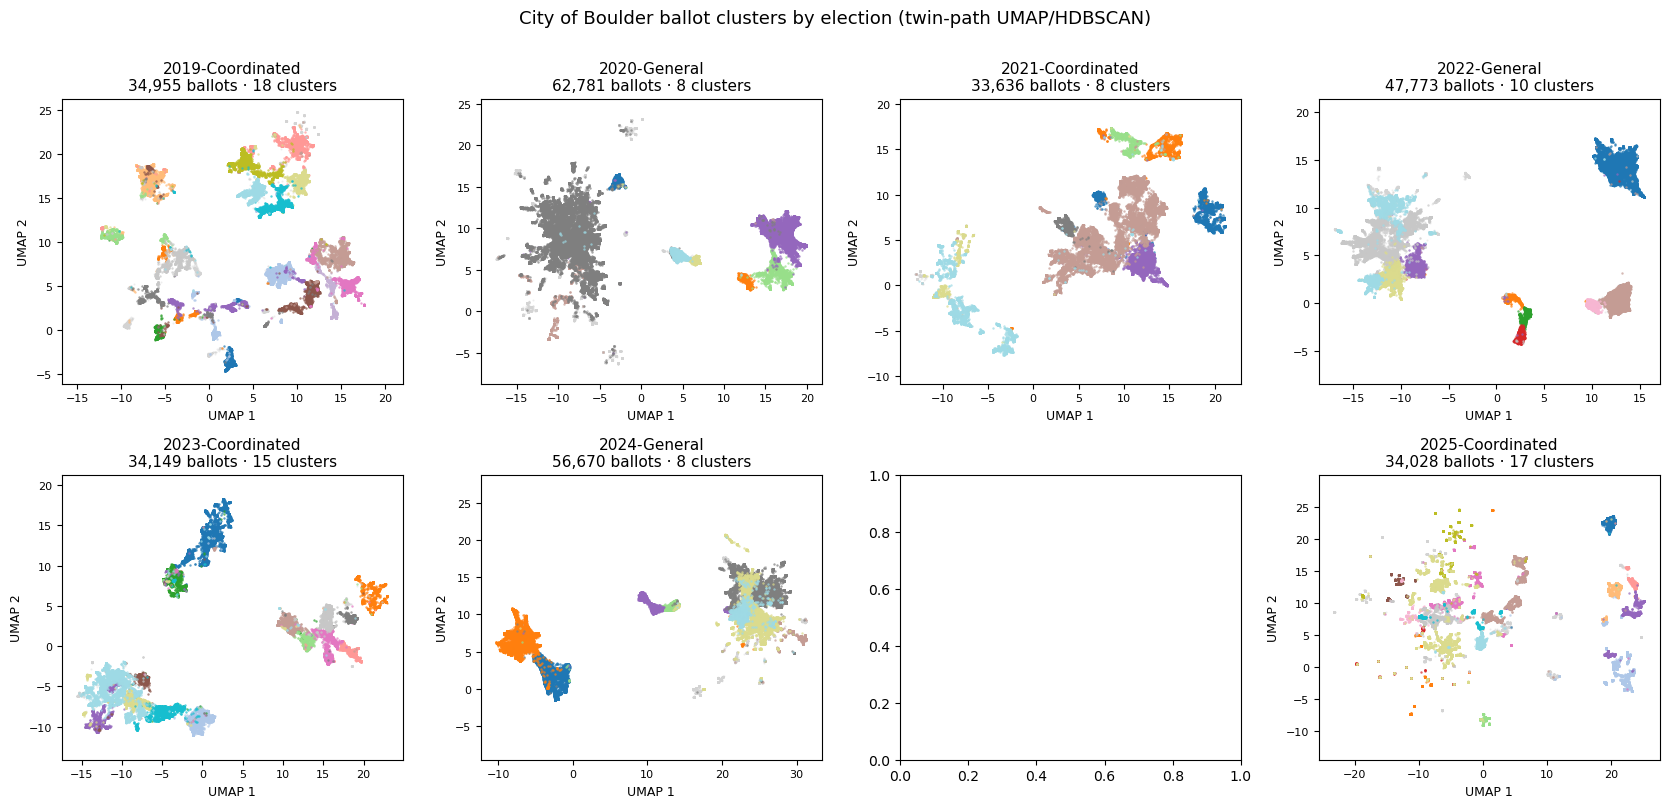

In [17]:
def plot_clusters(ax, embedding_2d, labels, title):
    noise = labels == -1
    if noise.any():
        ax.scatter(embedding_2d[noise, 0], embedding_2d[noise, 1],
                   s=2, c='lightgrey', alpha=0.4, linewidths=0)
    cluster_ids = sorted(set(labels) - {-1})
    palette = plt.cm.tab20(np.linspace(0, 1, max(len(cluster_ids), 1)))
    for cid, color in zip(cluster_ids, palette):
        mask = labels == cid
        ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                   s=3, c=[color], alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP 1', fontsize=9)
    ax.set_ylabel('UMAP 2', fontsize=9)
    ax.set_aspect('equal', adjustable='datalim')
    ax.tick_params(labelsize=8)


n = len(elections)
ncols = 4 if n > 4 else n
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, k in zip(axes, elections):
    if k in results:
        r = results[k]
        n_b = X_by_election[k].shape[0]
        plot_clusters(ax, r['embedding_2d'], r['labels'],
                      f"{k}\n{n_b:,} ballots · {r['n_clusters']} clusters")
for ax in axes[len(elections):]:
    ax.axis('off')

fig.suptitle('City of Boulder ballot clusters by election (twin-path UMAP/HDBSCAN)',
             y=1.005, fontsize=13)
plt.tight_layout()
plt.savefig(CLEAN_DIR / 'city-of-boulder-cluster-smallmultiples.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Per-cluster vote-share profiles

For each election, group ballots by cluster label and average each contest-choice column. A value near 1.0 means almost every ballot in the cluster marked that choice (NIST `HasIndication = yes`); a value near 0 means the cluster overwhelmingly did not mark it; intermediate values mean the cluster split.

Caveat: the cells average a mixture of `1`/`0` (actual marks) and `0`-from-`NaN` (contest wasn't on the ballot). For contests that are universal across all City of Boulder ballot styles, the average is interpretable as vote share; for contests that vary by ballot style within the city (rare), the denominator is the full cluster size, not the eligible-voter count. The profile tables are saved alongside the wide CSVs.


In [15]:
for k in elections:
    if k in results:
        df = cob[k].copy()
        df['cluster'] = results[k]['labels']
        cols = choice_cols_by_election[k]
        profile = df.groupby('cluster')[cols].mean().round(3)
        profile.insert(0, 'n_ballots', df.groupby('cluster').size())
        out = CLEAN_DIR / f'{k}-cluster-profiles.csv'
        profile.to_csv(out)
        print(f'  {out.name}: {profile.shape[0]} clusters × {profile.shape[1]-1} choice cols')


  2019-Coordinated-cluster-profiles.csv: 19 clusters × 33 choice cols
  2020-General-cluster-profiles.csv: 9 clusters × 105 choice cols
  2021-Coordinated-cluster-profiles.csv: 9 clusters × 46 choice cols
  2022-General-cluster-profiles.csv: 11 clusters × 128 choice cols
  2023-Coordinated-cluster-profiles.csv: 16 clusters × 50 choice cols
  2024-General-cluster-profiles.csv: 9 clusters × 106 choice cols
  2025-Coordinated-cluster-profiles.csv: 18 clusters × 33 choice cols


## Save ballot-level cluster assignments

The full ballot table with cluster labels and 2-D embedding coordinates appended is written to `data/processed/<election>-ballots-with-clusters.csv` for each election. Downstream pieces can `join` on `_ID/CvrNumber` (within an election) to attribute a ballot to its cluster without re-embedding.


In [16]:
for k in elections:
    if k in results:
        out = cob[k].copy()
        out['cluster'] = results[k]['labels']
        out['umap_x']  = results[k]['embedding_2d'][:, 0]
        out['umap_y']  = results[k]['embedding_2d'][:, 1]
        p = CLEAN_DIR / f'{k}-ballots-with-clusters.csv'
        out.to_csv(p, index=False)
        print(f'  {p.name}: {len(out):,} rows')


  2019-Coordinated-ballots-with-clusters.csv: 34,955 rows
  2020-General-ballots-with-clusters.csv: 62,781 rows
  2021-Coordinated-ballots-with-clusters.csv: 33,636 rows
  2022-General-ballots-with-clusters.csv: 47,773 rows
  2023-Coordinated-ballots-with-clusters.csv: 34,149 rows
  2024-General-ballots-with-clusters.csv: 56,670 rows
  2025-Coordinated-ballots-with-clusters.csv: 34,028 rows
